# Credit Risk Scorecard Model
### Krishnaprasad Seshadri | Data Analyst Portfolio Project

## Overview
This project builds a credit risk scorecard using Logistic Regression on 32,581 
real loan applications to predict the probability of a borrower defaulting.

The model prioritises interpretability over complexity — a deliberate choice 
reflecting the legal requirement in financial services to explain credit decisions 
to regulators and applicants.

## Key Results
- **ROC AUC Score:** 0.853
- **Default Recall:** 77%
- **Default Precision:** 50%
- **Dataset Size:** 32,581 loan applications
- **Default Rate:** 21.82%

## Tools Used
- Python (Pandas, NumPy, Scikit-learn)
- Matplotlib & Seaborn for visualisation
- Jupyter Notebook

## Step 1 — Import Libraries
We import libraries for data manipulation, visualisation, preprocessing 
and logistic regression modelling.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder

print("All libraries loaded successfully!")

All libraries loaded successfully!


## Step 2 — Load and Explore the Dataset
We load 32,581 loan applications with 12 features including applicant 
demographics, loan characteristics and credit history.

In [2]:
# Load the dataset
df = pd.read_csv('../data/credit_risk_dataset.csv')

# First look at the data
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
df.head()

Shape of dataset: (32581, 12)

Column names:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## Step 3 — Check for Missing Values
We identify missing values before modelling. Two columns require cleaning 
— employment length and interest rate.

In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


## Step 4 — Clean Missing Values
We fill missing values with the column median rather than the mean 
because the median is more robust to outliers in financial data.

In [4]:
# Fill missing values with median
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
                           
# Verify no missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


## Step 5 — Analyse Default Rate
We examine the ratio of defaulted to repaid loans. At 21.82% this dataset 
is far more balanced than typical fraud detection datasets, reducing 
the need for synthetic oversampling techniques like SMOTE.

In [5]:
# Check the default rate
default_count = df['loan_status'].value_counts()
print(default_count)

print("\nDefault rate:", round(df['loan_status'].mean() * 100, 2), "%")

loan_status
0    25473
1     7108
Name: count, dtype: int64

Default rate: 21.82 %


## Step 6 — Visualise Default Rate
A bar chart clearly communicates the class balance to non-technical 
stakeholders such as credit committee members or regulators.

C:\Users\krish\AppData\Local\Temp\ipykernel_17956\3670607768.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df, palette=['steelblue', 'red'])


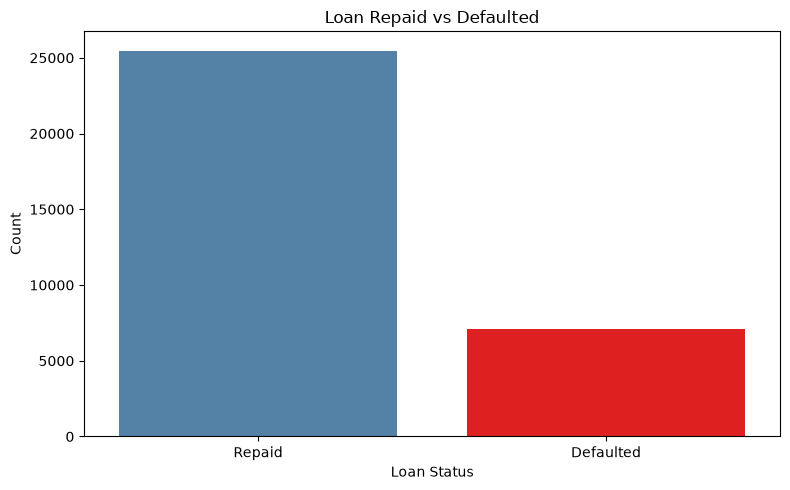

In [6]:
# Visualise the default rate
plt.figure(figsize=(8, 5))
sns.countplot(x='loan_status', data=df, palette=['steelblue', 'red'])
plt.title('Loan Repaid vs Defaulted')
plt.xticks([0, 1], ['Repaid', 'Defaulted'])
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Step 7 — Default Rate by Loan Grade
We examine how default rates vary across loan grades A through G. 
This validates the bank's existing internal risk assessment process.

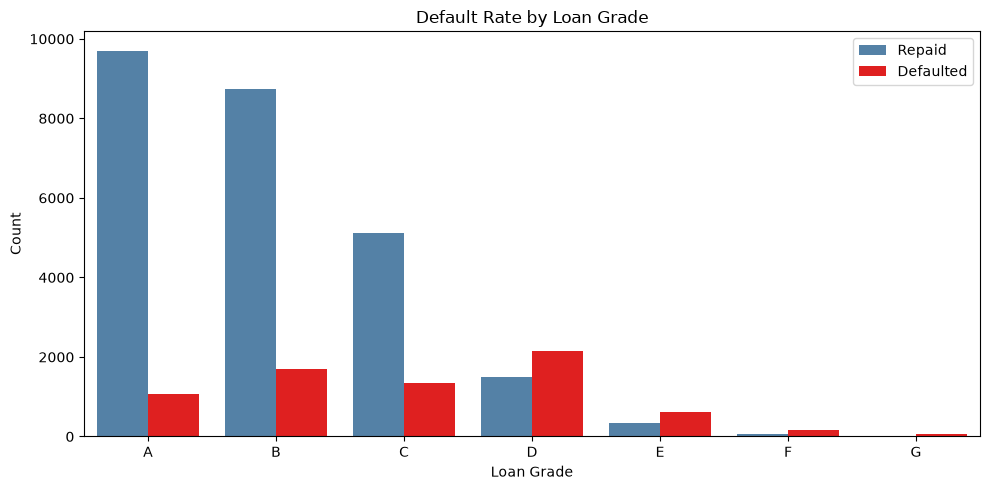

In [7]:
# Explore default rate by loan grade
plt.figure(figsize=(10, 5))
sns.countplot(x='loan_grade', hue='loan_status', data=df, 
              palette=['steelblue', 'red'],
              order=['A', 'B', 'C', 'D', 'E', 'F', 'G'])
plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Count')
plt.legend(['Repaid', 'Defaulted'])
plt.tight_layout()
plt.show()

## Step 8 — Default Rate by Home Ownership
We explore whether home ownership status affects default likelihood. 
Home ownership is a classic indicator of financial stability in credit risk.

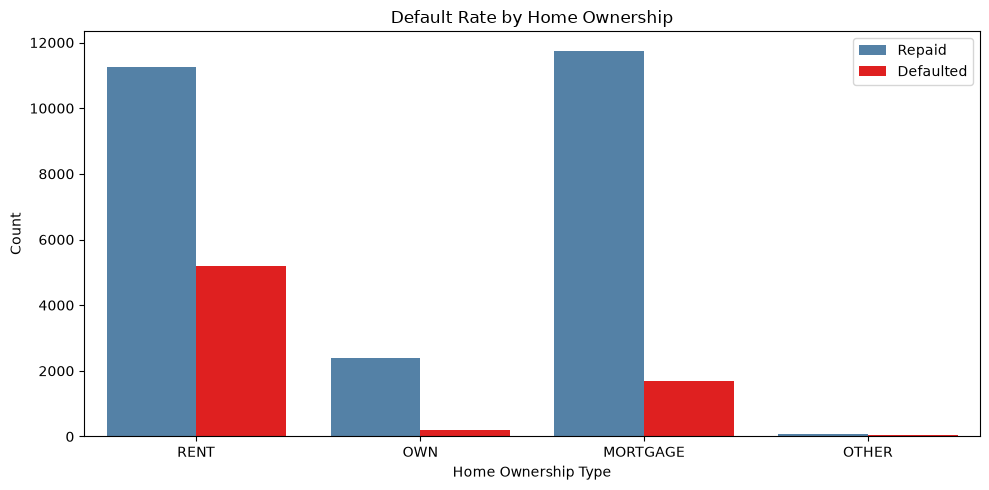

In [8]:
# Explore default rate by home ownership
plt.figure(figsize=(10, 5))
sns.countplot(x='person_home_ownership', hue='loan_status', data=df,
              palette=['steelblue', 'red'])
plt.title('Default Rate by Home Ownership')
plt.xlabel('Home Ownership Type')
plt.ylabel('Count')
plt.legend(['Repaid', 'Defaulted'])
plt.tight_layout()
plt.show()

## Step 9 — Default Rate by Loan Intent
We examine whether the purpose of the loan affects default likelihood. 
Borrower intent reveals behavioural patterns beyond pure financial metrics.

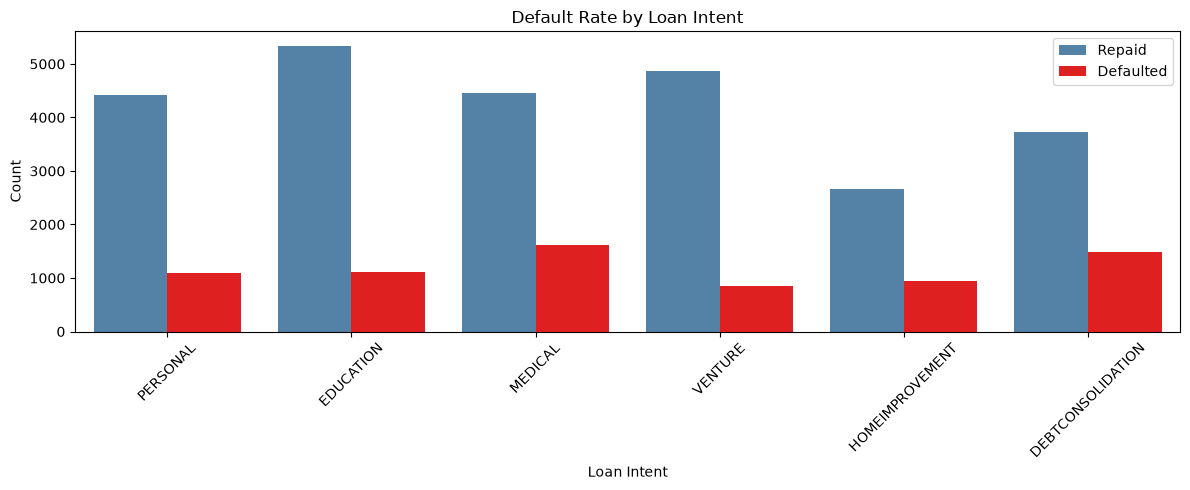

In [9]:
# Explore default rate by loan intent
plt.figure(figsize=(12, 5))
sns.countplot(x='loan_intent', hue='loan_status', data=df,
              palette=['steelblue', 'red'])
plt.title('Default Rate by Loan Intent')
plt.xlabel('Loan Intent')
plt.ylabel('Count')
plt.legend(['Repaid', 'Defaulted'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 10 — Correlation Matrix
We examine relationships between numerical features to identify strong 
predictors of default and check for multicollinearity which can 
destabilise Logistic Regression models.

In [ ]:
# Correlation heatmap of numerical features
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

## Step 11 — Encode Categorical Variables
We convert text columns to numerical format using Label Encoding 
because Logistic Regression can only process numerical inputs.

In [ ]:
# Convert categorical columns to numbers
le = LabelEncoder()

categorical_columns = ['person_home_ownership', 'loan_intent', 
                       'loan_grade', 'cb_person_default_on_file']

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

print("Categorical columns converted successfully!")
print(df.head())

## Step 12 — Prepare Data for Modelling
We separate features from the target variable and split 80/20 into 
training and test sets using stratified sampling to preserve the 
21.82% default rate in both sets.

In [ ]:
# Separate features from target
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nDefaults in training set:", y_train.sum())
print("Defaults in test set:", y_test.sum())

In [ ]:
# Build and train the Logistic Regression model
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

print("Model trained successfully!")

## Step 13 — Scale Features and Train Model
We apply StandardScaler to normalise all features to the same scale 
before training. This is essential for Logistic Regression because 
features on vastly different scales cause convergence problems.
We use class_weight='balanced' to handle remaining class imbalance 
without generating synthetic data.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Retrain with scaled data and more iterations
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=2000)
lr_model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

## Step 14 — Evaluate Model Performance
We evaluate on the unseen test set using precision, recall and F1 score. 
We focus on the defaulted loans row as this is the critical class 
for business decision making.

In [ ]:
# Evaluate the model
y_pred = lr_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=['Repaid', 'Defaulted']))

## Step 15 — Confusion Matrix
The confusion matrix shows raw prediction counts, making it easier 
to communicate model performance to non-technical stakeholders 
such as credit committees and risk managers.

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Repaid', 'Defaulted'],
            yticklabels=['Repaid', 'Defaulted'])
plt.title('Confusion Matrix — Credit Risk Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Step 16 — ROC AUC Score
The ROC AUC score measures the model's overall ability to distinguish 
between defaulted and repaid loans. A score above 0.80 is considered 
good for a Logistic Regression credit risk model.

In [ ]:
# ROC AUC Score
roc_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1])
print("ROC AUC Score:", round(roc_auc, 4))

## Step 17 — Feature Importance
Logistic Regression coefficients show exactly how much each feature 
contributes to the default probability score. This transparency is 
what makes Logistic Regression the preferred model in regulated 
financial environments where every decision must be explainable.

In [ ]:
# Feature importance via model coefficients
feature_importance = pd.Series(
    abs(lr_model.coef_[0]),
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, 
            y=feature_importance.index, 
            palette='Blues_r')
plt.title('Feature Importance — Credit Risk Model')
plt.xlabel('Coefficient Magnitude')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Additional Analysis — Default Rate by Loan Grade
Calculating exact default rates per loan grade to quantify the 
increase in risk from grade A to grade G.

In [ ]:
print(df.groupby('loan_grade')['loan_status'].mean() * 100)

## Conclusion
This project demonstrates a credit risk scorecard built on 32,581 real loan 
applications. The final Logistic Regression model achieves a ROC AUC score 
of 0.853 and catches 77% of actual defaults in unseen data.

Logistic Regression was deliberately chosen over more complex models because 
interpretability is a legal requirement in credit decisioning. The model's 
coefficients provide a clear, auditable explanation for every credit decision 
— something regulators and applicants are legally entitled to receive.

Key business insights uncovered during exploratory analysis:
- Default rates increase dramatically from loan grade A (9.96%) to grade G (98.44%)
- Renters default more than mortgage holders or outright owners
- Debt consolidation and medical loans carry the highest default rates
- Loan percent income and loan grade are the strongest predictors of default

**GitHub:** https://github.com/kris-sesh/credit-risk-scorecard